# Game Asset Extractor

This notebook extracts transparent PNG assets from one generated illustration.


In [2]:
# 1. Setup

# Install dependencies

# Use a tested Pillow version to avoid image-processing compatibility issues.
!pip -q install --no-cache-dir "pillow==11.3.0"

# Install the rest of the libraries used by this notebook.
!pip -q install transformers accelerate opencv-python matplotlib

import os
import json
import zipfile
import shutil
from pathlib import Path

import torch
import numpy as np
import cv2
import PIL
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

if device != "cuda":
    print("Warning: GPU is not enabled. Go to Runtime → Change runtime type → GPU.")

Device: cuda


In [3]:
# 2. Load Grounding DINO for text-based object detection

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

dino_model_id = "IDEA-Research/grounding-dino-tiny"
# For better quality, try:
# dino_model_id = "IDEA-Research/grounding-dino-base"

dino_processor = AutoProcessor.from_pretrained(dino_model_id)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(dino_model_id).to(device)

print("Loaded:", dino_model_id)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

Loaded: IDEA-Research/grounding-dino-tiny


In [4]:
# 3. Load SAM for segmentation from boxes

from transformers import SamModel, SamProcessor

sam_model_id = "facebook/sam-vit-base"
# For better quality but more GPU memory:
# sam_model_id = "facebook/sam-vit-large"
# sam_model_id = "facebook/sam-vit-huge"

sam_processor = SamProcessor.from_pretrained(sam_model_id)
sam_model = SamModel.from_pretrained(sam_model_id).to(device)

print("Loaded:", sam_model_id)

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Loaded: facebook/sam-vit-base


Saving ChatGPT Image May 27, 2026, 02_21_41 PM.png to ChatGPT Image May 27, 2026, 02_21_41 PM.png
Uploaded: ChatGPT Image May 27, 2026, 02_21_41 PM.png
Image size: 1254 1254


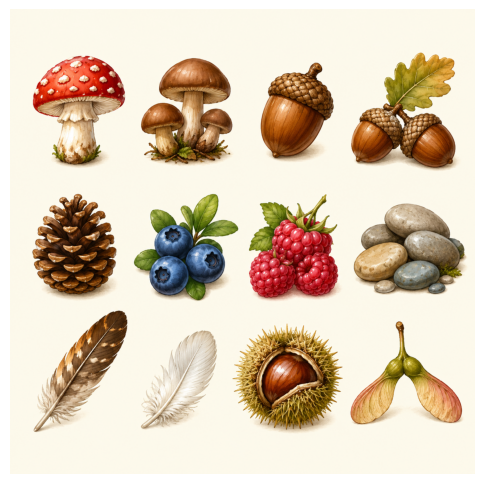

In [23]:
# 4. Upload the generated Inner Room image

uploaded = files.upload()

if not uploaded:
    raise ValueError("No file uploaded.")

input_filename = next(iter(uploaded.keys()))
input_path = Path(input_filename)

image = Image.open(input_path).convert("RGB")
W, H = image.size

print("Uploaded:", input_filename)
print("Image size:", W, H)

plt.figure(figsize=(6, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

In [30]:
# 5. Define the assets you want to extract

# Adjust this list for your generated image.
# Use visual descriptions if simple names are not detected well.
asset_prompts = [
     "mushroom",
     "blueberry with leaves",
     "stones",
     "feather",
     "berry with leaves",
     "acorn",
     "acorn with leaves",
     "pine cone"
]

# Each prompt should be separated by a period for Grounding DINO.
text_prompt = ". ".join(asset_prompts) + "."

print(text_prompt)

mushroom. blueberry with leaves. stones. feather. berry with leaves. acorn. acorn with leaves. pine cone.


In [ ]:
# 6. Detect boxes
def run_grounding_dino(image, text_prompt, box_threshold=0.25, text_threshold=0.25):
    """
    Run Grounding DINO on an image using a text prompt.

    Returns:
        A list of detections:
        [
            {
                "label": "mushroom",
                "score": 0.81,
                "bbox": [x1, y1, x2, y2]
            }
        ]
    """

    # Convert the image and text prompt into model inputs.
    inputs = dino_processor(
        images=image,
        text=text_prompt,
        return_tensors="pt"
    ).to(device)

    # Run inference.
    with torch.no_grad():
        outputs = dino_model(**inputs)

    # Convert raw model outputs into boxes, scores, and labels.
    # target_sizes expects (height, width), not (width, height).
    results = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=box_threshold,
        text_threshold=text_threshold,
        target_sizes=[(image.height, image.width)]
    )[0]

    # Convert tensor outputs into plain Python dictionaries.
    detections = []

    for box, score, label in zip(
        results["boxes"],
        results["scores"],
        results["labels"]
    ):
        x1, y1, x2, y2 = box.detach().cpu().numpy().tolist()

        detections.append({
            "label": str(label),
            "score": float(score.detach().cpu().item()),
            "bbox": [float(x1), float(y1), float(x2), float(y2)]
        })

    return detections

detections = run_grounding_dino(
    image,
    text_prompt,
    box_threshold=0.22,
    text_threshold=0.22
)

print("Detections:", len(detections))
for i, det in enumerate(detections):
    print(i, det["label"], round(det["score"], 3), det["bbox"])

Detections: 26
0 pine cone 0.571 [59.25202560424805, 496.2301330566406, 288.89019775390625, 770.874755859375]
1 stones 0.572 [926.8001098632812, 520.5833129882812, 1224.482421875, 771.0029907226562]
2 mushroom 0.419 [400.7689208984375, 130.73268127441406, 596.845947265625, 385.1524353027344]
3 berry with leaves 0.461 [643.2750854492188, 500.23382568359375, 887.4293823242188, 779.4657592773438]
4 mushroom 0.355 [352.547119140625, 251.02378845214844, 470.5097961425781, 402.13116455078125]
5 mushroom 0.485 [59.86919021606445, 122.39351654052734, 311.4731750488281, 419.99578857421875]
6 blueberry 0.333 [374.5411376953125, 663.4794921875, 481.75238037109375, 772.4008178710938]
7 blueberry 0.274 [388.76654052734375, 579.5261840820312, 493.3008117675781, 671.7412719726562]
8 blueberry 0.294 [474.37054443359375, 632.2169189453125, 580.6353149414062, 738.9885864257812]
9 feather 0.317 [351.4903259277344, 863.6407470703125, 560.005615234375, 1133.4512939453125]
10 acorn leaves 0.309 [1005.359680

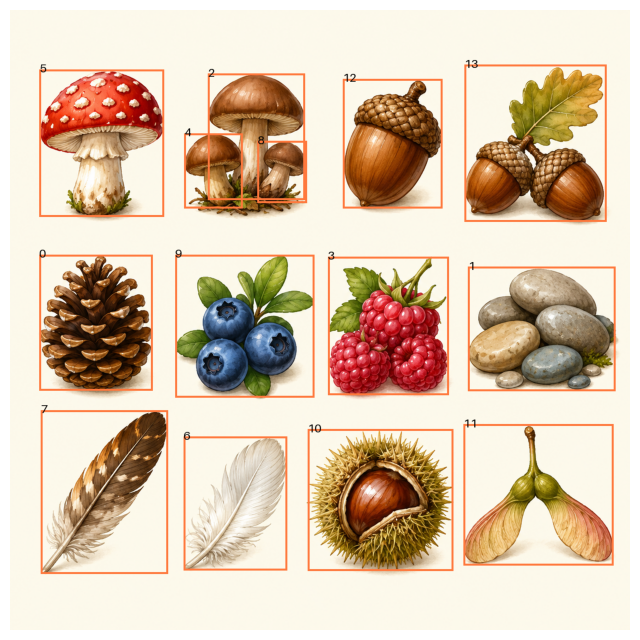

In [ ]:
# 7. Visualize detected boxes
# ============================================================
# Visualize detected boxes
# ============================================================
# Draw bounding boxes on a copy of the image so we can inspect
# whether Grounding DINO detected the correct objects.

def draw_boxes(image, detections):
    preview = image.copy().convert("RGBA")
    draw = ImageDraw.Draw(preview)

    for i, det in enumerate(detections):
        x1, y1, x2, y2 = det["bbox"]

        # Draw the detection box.
        draw.rectangle(
            [x1, y1, x2, y2],
            outline=(255, 120, 60, 255),
            width=4
        )

        # Draw the detection index near the top-left corner.
        draw.text(
            (x1, max(0, y1 - 18)),
            str(i),
            fill=(0, 0, 0, 255),
            font_size=24
        )

    return preview


box_preview = draw_boxes(image, detections)

plt.figure(figsize=(8, 12))
plt.imshow(box_preview)
plt.axis("off")
plt.show()

## Optional manual cleanup

If detections are messy, edit the next cell.

You can:
- remove unwanted detection indexes
- rename an item
- manually adjust bounding boxes
- add missing boxes manually

Bounding box format:

```python
[x1, y1, x2, y2]
```

In [ ]:
# 8. Review / edit detections

# Example:
# keep_indexes = [0, 1, 2, 3, 4, 5, 9, 14, 17, 19, 20, 21, 22, 24]
# detections = [detections[i] for i in keep_indexes]

# Example manual edit:
# detections[0]["label"] = "journal"
# detections[0]["bbox"] = [320, 1300, 850, 1680]

# Example manual add:
# detections.append({
#     "label": "tea cup",
#     "score": 1.0,
#     "bbox": [120, 1900, 310, 2150]
# })

print("Current detections:")
for i, det in enumerate(detections):
    print(i, det["label"], round(det["score"], 3), det["bbox"])

Current detections:
0 pine cone 0.571 [59.25202560424805, 496.2301330566406, 288.89019775390625, 770.874755859375]
1 stones 0.572 [926.8001098632812, 520.5833129882812, 1224.482421875, 771.0029907226562]
2 mushroom 0.419 [400.7689208984375, 130.73268127441406, 596.845947265625, 385.1524353027344]
3 berry with leaves 0.461 [643.2750854492188, 500.23382568359375, 887.4293823242188, 779.4657592773438]
4 mushroom 0.355 [352.547119140625, 251.02378845214844, 470.5097961425781, 402.13116455078125]
5 mushroom 0.485 [59.86919021606445, 122.39351654052734, 311.4731750488281, 419.99578857421875]
6 feather 0.317 [351.4903259277344, 863.6407470703125, 560.005615234375, 1133.4512939453125]
7 feather 0.338 [62.94191360473633, 810.374267578125, 319.0229187011719, 1140.3701171875]
8 mushroom 0.28 [500.5712890625, 266.69097900390625, 600.3560180664062, 391.7103271484375]
9 blueberry acorn leaves 0.271 [334.46038818359375, 496.4365234375, 615.701904296875, 784.668212890625]
10 acorn acorn leaves 0.286 [

In [ ]:
# 9. Generate masks with SAM

def sam_mask_from_box(image, bbox):
    """
    Generate one segmentation mask using SAM from a bounding box.

    Args:
        image: Original PIL image.
        bbox: Bounding box in [x1, y1, x2, y2] format.

    Returns:
        A 2D NumPy mask:
        - 0 means background
        - 255 means object
    """

    # SAM expects boxes in this nested format:
    # [
    #   [
    #     [x1, y1, x2, y2]
    #   ]
    # ]
    # Meaning: one image, one box.
    input_boxes = [[bbox]]

    # Convert the image and box into SAM model inputs.
    inputs = sam_processor(
        image,
        input_boxes=input_boxes,
        return_tensors="pt"
    ).to(device)

    # Run SAM inference.
    # multimask_output=True asks SAM to generate multiple candidate masks.
    with torch.no_grad():
        outputs = sam_model(**inputs, multimask_output=True)

    # Resize masks back to the original image size.
    masks = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu()
    )[0]

    # Select the best candidate mask using SAM's IoU confidence scores.
    iou_scores = outputs.iou_scores.detach().cpu()[0, 0]
    best_idx = int(torch.argmax(iou_scores).item())

    # Convert the selected mask to a 0/255 uint8 image mask.
    mask = masks[0, best_idx].numpy().astype(np.uint8) * 255

    return mask


masks = []

for i, det in enumerate(detections):
    print("Masking:", i, det["label"])

    mask = sam_mask_from_box(image, det["bbox"])
    masks.append(mask)

print("Generated masks:", len(masks))

Masking: 0 pine cone
Masking: 1 stones
Masking: 2 mushroom
Masking: 3 berry with leaves
Masking: 4 mushroom
Masking: 5 mushroom
Masking: 6 feather
Masking: 7 feather
Masking: 8 mushroom
Masking: 9 blueberry acorn leaves
Masking: 10 acorn acorn leaves
Masking: 11 acorn
Masking: 12 acorn
Masking: 13 acorn
Generated masks: 14


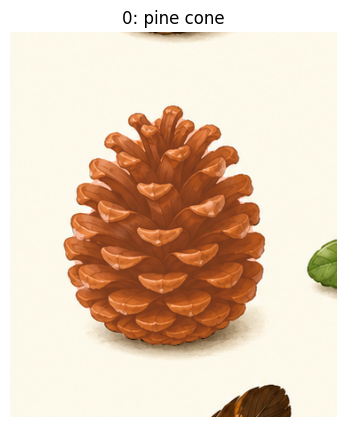

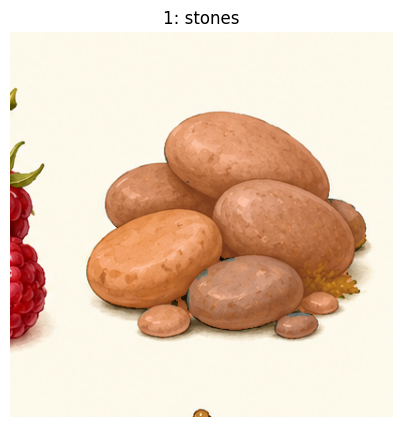

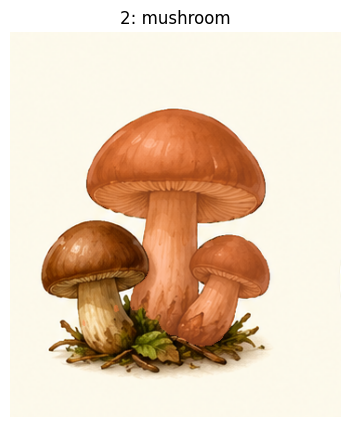

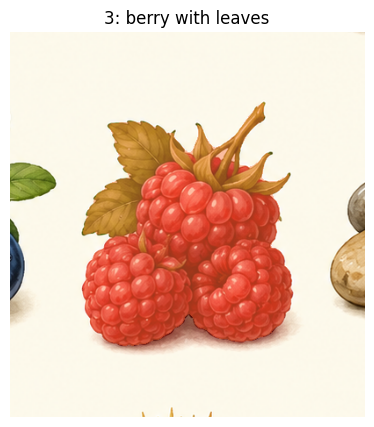

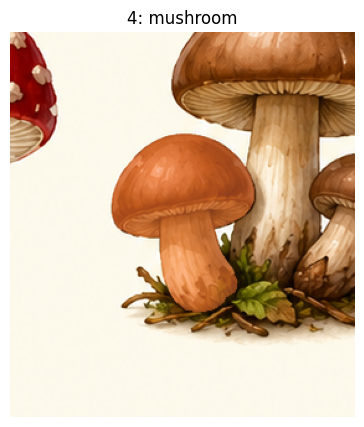

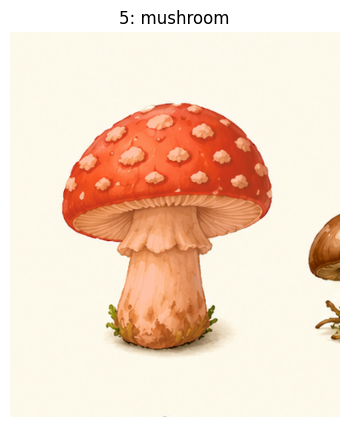

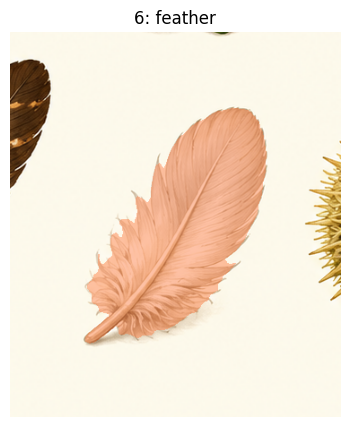

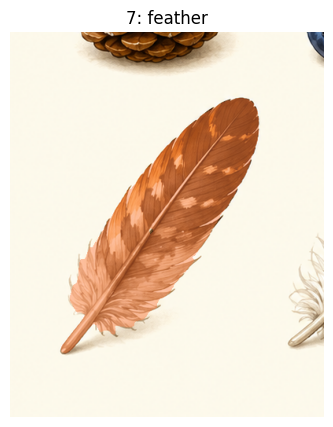

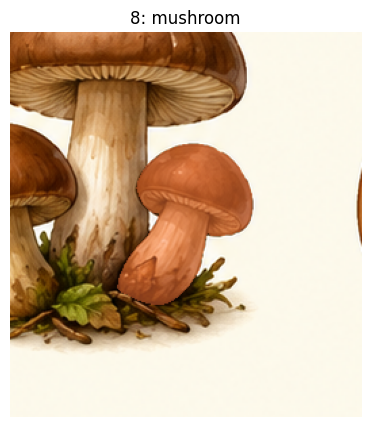

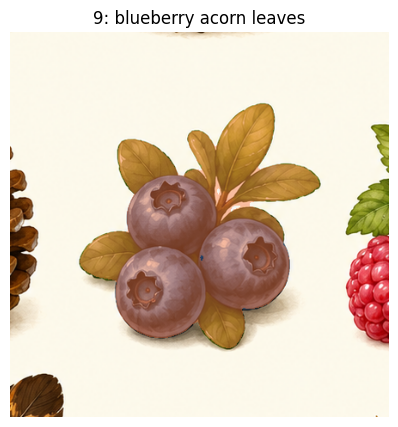

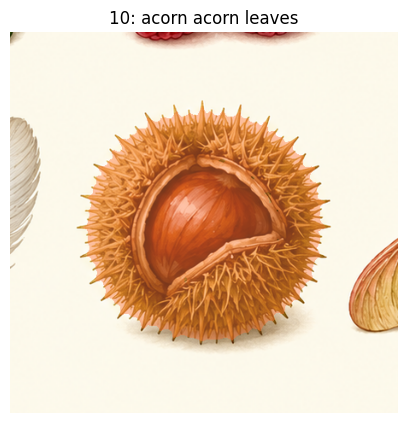

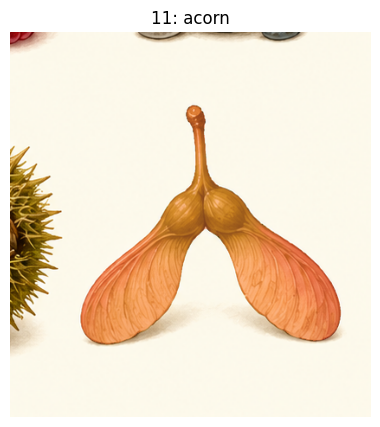

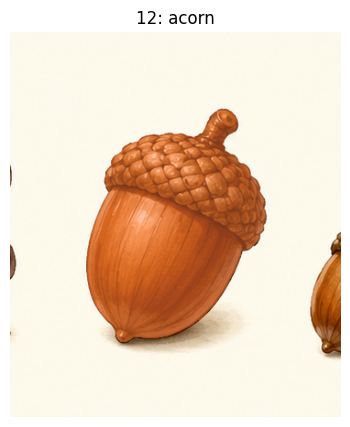

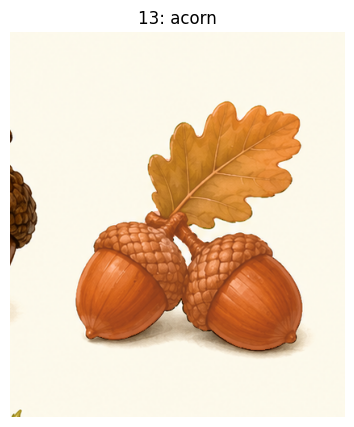

In [ ]:
# 10. Preview masks

def overlay_mask(image, mask, color=(255, 120, 60), alpha=0.45):
    """
    Overlay a binary mask on top of the original image.

    Args:
        image: Original PIL image.
        mask: 2D mask array where object pixels are > 0.
        color: RGB color used to highlight the mask.
        alpha: Overlay transparency.

    Returns:
        A PIL image with the mask highlighted.
    """
    img = np.array(image.convert("RGBA")).copy()

    # Convert mask to boolean: True for object pixels.
    m = mask > 0

    # Create a colored overlay image.
    overlay = img.copy()
    overlay[m, 0] = color[0]
    overlay[m, 1] = color[1]
    overlay[m, 2] = color[2]

    # Blend the overlay with the original image only on masked pixels.
    img[m] = (
        img[m] * (1 - alpha) +
        overlay[m] * alpha
    ).astype(np.uint8)

    return Image.fromarray(img)


W, H = image.size

for i, (det, mask) in enumerate(zip(detections, masks)):
    preview = overlay_mask(image, mask)

    x1, y1, x2, y2 = map(int, det["bbox"])
    pad = 80

    crop = preview.crop((
        max(0, x1 - pad),
        max(0, y1 - pad),
        min(W, x2 + pad),
        min(H, y2 + pad)
    ))

    plt.figure(figsize=(5, 5))
    plt.title(f'{i}: {det["label"]}')
    plt.imshow(crop)
    plt.axis("off")
    plt.show()

## Optional mask refinement

For UI assets, edge quality matters.

The export step below will:
- create unique filenames for repeated detections with the same label
- optionally create game-ready transparent mask/shadow images from the same item shape
- remove small noise
- smooth and defringe mask edges
- crop with padding
- preserve original coordinates in `layout.json`

If a mask is bad, adjust the bounding box in Step 7 and rerun from Step 9.

In [ ]:
# 11. Export transparent PNG assets + layout.json

# Toggle this off if you only need item PNGs and do not need matching masks/shadows.
GENERATE_MASK_IMAGES = True

# Game-ready mask style: transparent background with a shadow-colored item shape.
MASK_COLOR = (65, 58, 52)
MASK_OPACITY = 0.62

# Optional custom export prefix. Leave empty to use detection labels as filenames.
# Example: CUSTOM_ASSET_NAME = "fruit" creates fruit_01.png and fruit_mask_01.png.
CUSTOM_ASSET_NAME = ""

output_dir = Path("game_extracted_assets")
items_dir = output_dir / "items"
masks_dir = output_dir / "masks"

if output_dir.exists():
    shutil.rmtree(output_dir)

items_dir.mkdir(parents=True)
if GENERATE_MASK_IMAGES:
    masks_dir.mkdir(parents=True)

def slugify(text):
    text = text.lower().strip()
    text = "".join(ch if ch.isalnum() else "_" for ch in text)
    while "__" in text:
        text = text.replace("__", "_")
    return text.strip("_") or "asset"

asset_id_counts = {}
used_asset_ids = set()

def make_export_names(label):
    custom_base = slugify(CUSTOM_ASSET_NAME) if CUSTOM_ASSET_NAME.strip() else ""
    if custom_base:
        next_index = asset_id_counts.get(custom_base, 0) + 1

        while True:
            item_id = f"{custom_base}_{next_index:02d}"
            mask_id = f"{custom_base}_mask_{next_index:02d}"
            if item_id not in used_asset_ids and mask_id not in used_asset_ids:
                break
            next_index += 1

        asset_id_counts[custom_base] = next_index
        used_asset_ids.add(item_id)
        used_asset_ids.add(mask_id)
        return item_id, mask_id

    base = slugify(label)
    next_index = asset_id_counts.get(base, 0) + 1

    while True:
        candidate = base if next_index == 1 else f"{base}_{next_index:02d}"
        if candidate not in used_asset_ids:
            break
        next_index += 1

    asset_id_counts[base] = next_index
    used_asset_ids.add(candidate)
    return candidate, f"{candidate}_mask"

def refine_mask(mask, expand_px=1, feather_px=1.6, supersample=4):
    # Binary threshold
    binary = (mask > 0).astype(np.uint8) * 255

    # Remove tiny noise
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # Fill small holes / expand slightly
    if expand_px > 0:
        kernel = np.ones((expand_px * 2 + 1, expand_px * 2 + 1), np.uint8)
        binary = cv2.dilate(binary, kernel, iterations=1)

    # Supersampled feathering gives the transparent PNG a softer, less jagged alpha edge.
    if supersample > 1:
        h, w = binary.shape
        high_res = cv2.resize(binary, (w * supersample, h * supersample), interpolation=cv2.INTER_CUBIC)
        sigma = feather_px * supersample
        high_res = cv2.GaussianBlur(high_res, (0, 0), sigmaX=sigma, sigmaY=sigma)
        alpha = cv2.resize(high_res, (w, h), interpolation=cv2.INTER_AREA)
    elif feather_px > 0:
        alpha = cv2.GaussianBlur(binary, (0, 0), sigmaX=feather_px, sigmaY=feather_px)
    else:
        alpha = binary

    return np.clip(alpha, 0, 255).astype(np.uint8)

def defringe_rgba(crop, alpha, solid_threshold=220):
    rgba = np.array(crop.convert("RGBA"))
    alpha_arr = np.array(alpha)

    # Replace edge/background RGB with nearby solid object colors; alpha still controls visibility.
    inpaint_mask = (alpha_arr < solid_threshold).astype(np.uint8) * 255
    if np.any(alpha_arr >= solid_threshold) and np.any(inpaint_mask):
        rgba[:, :, :3] = cv2.inpaint(rgba[:, :, :3], inpaint_mask, 3, cv2.INPAINT_TELEA)

    rgba[:, :, 3] = alpha_arr
    return Image.fromarray(rgba)

def make_shadow_mask_png(alpha, color=MASK_COLOR, opacity=MASK_OPACITY):
    alpha_arr = np.array(alpha).astype(np.float32)
    shadow_alpha = np.clip(alpha_arr * opacity, 0, 255).astype(np.uint8)
    rgba = np.zeros((shadow_alpha.shape[0], shadow_alpha.shape[1], 4), dtype=np.uint8)
    rgba[:, :, 0] = color[0]
    rgba[:, :, 1] = color[1]
    rgba[:, :, 2] = color[2]
    rgba[:, :, 3] = shadow_alpha
    return Image.fromarray(rgba)

def export_asset(image, mask, det, padding=32):
    label = det["label"]
    asset_id, mask_id = make_export_names(label)
    x1, y1, x2, y2 = map(int, det["bbox"])

    refined = refine_mask(mask, expand_px=1, feather_px=1.6, supersample=4)

    # Use mask bounds instead of only detection box
    ys, xs = np.where(refined > 5)
    if len(xs) > 0 and len(ys) > 0:
        x1, x2 = xs.min(), xs.max()
        y1, y2 = ys.min(), ys.max()

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(image.width, x2 + padding)
    y2 = min(image.height, y2 + padding)

    image_rgba = image.convert("RGBA")
    crop = image_rgba.crop((x1, y1, x2, y2))

    mask_crop = refined[y1:y2, x1:x2]
    alpha = Image.fromarray(mask_crop).convert("L")

    result = defringe_rgba(crop, alpha)

    item_path = items_dir / f"{asset_id}.png"

    result.save(item_path)

    mask_src = None
    if GENERATE_MASK_IMAGES:
        mask_path = masks_dir / f"{mask_id}.png"
        mask_image = make_shadow_mask_png(alpha)
        mask_image.save(mask_path)
        mask_src = f"masks/{mask_id}.png"

    item = {
        "id": asset_id,
        "label": label,
        "src": f"items/{asset_id}.png",
        "x": int(x1),
        "y": int(y1),
        "width": int(x2 - x1),
        "height": int(y2 - y1),
        "bbox": [int(v) for v in det["bbox"]],
        "score": det["score"],
        "interactive": True
    }

    if mask_src:
        item["mask"] = mask_src
        item["shadow"] = mask_src

    return item

layout = {
    "canvas": {
        "width": W,
        "height": H,
        "source": str(input_filename)
    },
    "items": []
}

for det, mask in zip(detections, masks):
    item = export_asset(image, mask, det, padding=36)
    layout["items"].append(item)

layout_path = output_dir / "layout.json"
layout_path.write_text(json.dumps(layout, indent=2, ensure_ascii=False), encoding="utf-8")

print("Exported assets:")
for item in layout["items"]:
    print(item["id"], item["src"], item["x"], item["y"], item["width"], item["height"])

Exported assets:
pine_cone items/pine_cone.png 21 459 305 349
stones items/stones.png 888 485 366 322
mushroom items/mushroom.png 358 93 280 335
berry_with_leaves items/berry_with_leaves.png 606 462 317 355
mushroom_02 items/mushroom_02.png 314 213 194 223
mushroom_03 items/mushroom_03.png 22 86 326 371
feather items/feather.png 315 828 281 341
feather_02 items/feather_02.png 25 774 330 404
mushroom_04 items/mushroom_04.png 459 229 179 198
blueberry_acorn_leaves items/blueberry_acorn_leaves.png 295 460 358 363
acorn_acorn_leaves items/acorn_acorn_leaves.png 569 817 361 352
acorn items/acorn.png 879 803 375 355
acorn_02 items/acorn_02.png 637 105 274 334
acorn_03 items/acorn_03.png 881 79 359 386


In [ ]:
# 13. Zip and download

zip_path = Path("game_extracted_assets.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for file in output_dir.rglob("*"):
        z.write(file, file.relative_to(output_dir))
    z.write(input_path, input_path.name)

print("ZIP:", zip_path)
files.download(zip_path)

ZIP: inner_room_extracted_assets.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>